<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=300807538" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import sys
import matplotlib.pyplot as plt

# --- 1. LE REMÈDE ANTI-CRASH PYTORCH (OBLIGATOIRE EN PREMIER) ---
import torch
# On force PyTorch à charger ses modules CUDA tout de suite
_ = torch.cuda.is_available() 
print(f"✅ PyTorch {torch.__version__} est réveillé et prêt.")

# --- 2. TÉLÉCHARGEMENT DE TA LIBRAIRIE ---
# J'utilise la branche dev-leila2 comme sur tes précédentes captures. 
# Si tu as fusionné sur main, remplace 'dev-leila2' par 'main' dans l'URL.
GITHUB_RAW_URL = "https://raw.githubusercontent.com/wekt2k04/NeuroSight_AI/dev-leila2/notebooks/data_pipeline.py"

print("📥 Téléchargement de data_pipeline.py...")
!wget -q -O data_pipeline.py {GITHUB_RAW_URL}

if '/kaggle/working' not in sys.path:
    sys.path.append('/kaggle/working')

# --- 3. IMPORTATION ---
try:
    # Nettoyage du cache au cas où tu relances la cellule
    if 'data_pipeline' in sys.modules:
        import importlib
        importlib.reload(sys.modules['data_pipeline'])
        
    from data_pipeline import get_dataloaders, show_sample_batch
    print("✅ Fichier data_pipeline.py importé avec succès sans crash !")
except Exception as e:
    print(f"❌ Erreur : {e}")

# --- 4. LE NOUVEAU DATASET ---
# Basé sur ta capture d'écran, voici le chemin exact
DATA_DIR = '/kaggle/input/datasets/wilfriedtsetse04/neurosight-ai-dataset/neurosight-mri-dataset/OriginalDataset'

if os.path.exists(DATA_DIR):
    print(f"📂 Dataset trouvé à l'adresse : {DATA_DIR}")
else:
    print(f"❌ ERREUR : Dataset introuvable. As-tu bien fait '+ Add Input' dans Kaggle ?")

✅ PyTorch 2.9.0+cu126 est réveillé et prêt.
📥 Téléchargement de data_pipeline.py...
✅ Fichier data_pipeline.py importé avec succès sans crash !
📂 Dataset trouvé à l'adresse : /kaggle/input/datasets/wilfriedtsetse04/neurosight-ai-dataset/neurosight-mri-dataset/OriginalDataset


🚀 Usine à données prête ! Classes détectées : ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


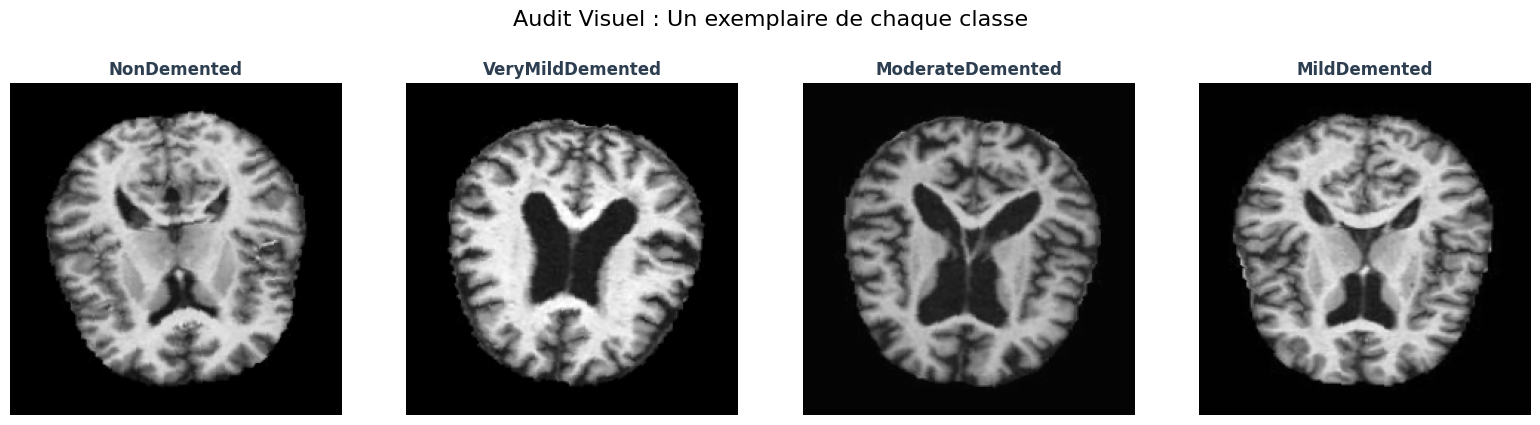

In [2]:
# ==========================================
# CELLULE 2 : CRÉATION DES LOADERS & VISUALISATION DE CHAQUE CLASSE
# ==========================================
import matplotlib.pyplot as plt
import torch

# 1. Création des DataLoaders à partir de ton dataset privé
DATA_DIR = '/kaggle/input/datasets/wilfriedtsetse04/neurosight-ai-dataset/neurosight-mri-dataset/OriginalDataset'

# On appelle la fonction de notre librairie pour générer l'usine à données
train_loader, test_loader, classes = get_dataloaders(DATA_DIR, batch_size=32)

print(f"🚀 Usine à données prête ! Classes détectées : {classes}")

# 2. Récupérer le premier lot (batch) d'images
images, labels = next(iter(train_loader))

# Dénormalisation pour l'affichage (Annuler les maths de PyTorch pour nos yeux)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
images = images * std + mean
images = torch.clamp(images, 0, 1) # Sécurité pour éviter les pixels aberrants

# 3. Extraire et afficher exactement UNE image par classe
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
classes_trouvees = set()

# On fouille dans le lot de 32 images...
for img, label in zip(images, labels):
    nom_classe = classes[label]
    
    # ... et si on tombe sur une classe qu'on n'a pas encore affichée :
    if nom_classe not in classes_trouvees:
        index = len(classes_trouvees)
        ax = axes[index]
        
        # Affichage de l'image (Transformation CHW -> HWC)
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(nom_classe, fontsize=12, fontweight='bold', color='#2c3e50')
        ax.axis('off')
        
        classes_trouvees.add(nom_classe)
        
        # Si on a trouvé un exemplaire des 4 classes, on arrête de fouiller
        if len(classes_trouvees) == 4:
            break

plt.suptitle("Audit Visuel : Un exemplaire de chaque classe", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [14]:
# ==============================================================================
# CELLULE 3 : L'USINE À INTELLIGENCE (TRAINING & EVALUATION EN 2 PHASES)
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau # <-- L'import corrigé !
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import time
import copy

# ---------------------------------------------------------
# 1. CONSTRUCTION DE L'ARCHITECTURE
# ---------------------------------------------------------
def build_model(num_classes=4, freeze_features=True):
    print("🧠 Chargement de l'architecture EfficientNet-B0...")
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    
    if freeze_features:
        for param in model.parameters():
            param.requires_grad = False
            
    num_ftrs = model.classifier[1].in_features
    # Le Dropout à 40% force l'IA à ne pas apprendre par cœur
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(num_ftrs, num_classes)
    )
    return model

# ---------------------------------------------------------
# 2. MOTEUR D'ENTRAÎNEMENT
# ---------------------------------------------------------
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, num_epochs=25, patience=5, phase_name=""):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'\n{phase_name} - Étape {epoch+1}/{num_epochs} ' + '-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase.capitalize():<5} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                # Activation du Scheduler si on est en Phase 2
                if scheduler is not None:
                    scheduler.step(epoch_loss)
                    courant_lr = optimizer.param_groups[0]['lr']
                    print(f"   L.R. actuel : {courant_lr:.6e}")

                # --- SAUVEGARDE & EARLY STOPPING ---
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), 'best_model.pth')
                    print(f"🌟 Amélioration ! Modèle sauvegardé.")
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"\n🛑 EARLY STOPPING DÉCLENCHÉ. L'IA a arrêté de s'améliorer.")
            break

    model.load_state_dict(best_model_wts)
    return model, history, best_val_loss

# ---------------------------------------------------------
# 3. ÉVALUATION ET MÉTRIQUES MÉDICALES
# ---------------------------------------------------------
def evaluate_model(model, val_loader, class_names):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.eval()
    all_preds, all_labels = [], []
    
    print("\n🔍 Génération du rapport d'évaluation clinique...")
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    print("\n" + "="*55)
    print("📊 RAPPORT DES MÉTRIQUES MÉDICALES (SUR DONNÉES DE TEST)")
    print("="*55)
    # zero_division=0 évite les warnings si une classe n'est jamais prédite au début
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Matrice de Confusion - NeuroSight AI', fontsize=14, pad=15)
    plt.ylabel('Vrai Diagnostic (Médecin)', fontsize=12, fontweight='bold')
    plt.xlabel('Prédiction de l\'IA', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 4. ORCHESTRATION EN 2 PHASES
# ---------------------------------------------------------
def run_full_training(train_loader, val_loader, class_names):
    # --- PHASE 1 : WARM-UP ---
    print("\n" + "="*50)
    print("🔥 PHASE 1 : WARM-UP (Entraînement de la tête uniquement)")
    print("="*50)
    model = build_model(num_classes=len(class_names), freeze_features=True)
    criterion = nn.CrossEntropyLoss()
    
    # Apprentissage rapide (lr=1e-3) pour placer les poids initiaux
    optimizer_phase1 = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-2)
    # Seulement 5 epochs max, on s'arrête si ça stagne après 2
    model, _, _ = train_model(model, train_loader, val_loader, criterion, optimizer_phase1, 
                              num_epochs=5, patience=2, phase_name="[PHASE 1]")
    
    # --- PHASE 2 : DEEP FINE-TUNING ---
    print("\n" + "="*50)
    print("🚀 PHASE 2 : DEEP FINE-TUNING (Décongélation totale d'EfficientNet)")
    print("="*50)
    
    # On débloque toutes les couches pour qu'il étudie vraiment l'IRM
    for param in model.parameters():
        param.requires_grad = True
        
    # Le Learning Rate est divisé par 20 (5e-5) pour "sculpter" sans détruire les bases
    optimizer_phase2 = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-3)
    
    # Le planificateur (Scheduler) divise le LR par 2 si l'IA stagne pendant 2 epochs
    scheduler = ReduceLROnPlateau(optimizer_phase2, mode='min', factor=0.5, patience=2)
    
    # On laisse le temps au modèle (25 epochs, patience de 5)
    best_model, history, _ = train_model(model, train_loader, val_loader, criterion, optimizer_phase2, 
                                         scheduler=scheduler, num_epochs=25, patience=5, phase_name="[PHASE 2]")
    
    # --- ÉVALUATION FINALE ---
    evaluate_model(best_model, val_loader, class_names)
    print("\n✅ LIVRABLE FINAL DISPONIBLE : 'best_model.pth'")
    return best_model, history



🧠 Démarrage du Workflow MLOps (GridSearch + Training + Evaluation)...

🔥 PHASE 1 : WARM-UP (Entraînement de la tête uniquement)
🧠 Chargement de l'architecture EfficientNet-B0...

[PHASE 1] - Étape 1/5 --------------------
Train | Loss: 1.2076 | Acc: 0.4508
Val   | Loss: 1.1765 | Acc: 0.4680
🌟 Amélioration ! Modèle sauvegardé.

[PHASE 1] - Étape 2/5 --------------------
Train | Loss: 1.0869 | Acc: 0.5256
Val   | Loss: 1.1863 | Acc: 0.4492

[PHASE 1] - Étape 3/5 --------------------
Train | Loss: 1.0699 | Acc: 0.5367
Val   | Loss: 1.1199 | Acc: 0.4742
🌟 Amélioration ! Modèle sauvegardé.

[PHASE 1] - Étape 4/5 --------------------
Train | Loss: 1.0397 | Acc: 0.5527
Val   | Loss: 1.0373 | Acc: 0.5391
🌟 Amélioration ! Modèle sauvegardé.

[PHASE 1] - Étape 5/5 --------------------
Train | Loss: 1.0171 | Acc: 0.5627
Val   | Loss: 1.0806 | Acc: 0.5023

🚀 PHASE 2 : DEEP FINE-TUNING (Décongélation totale d'EfficientNet)

[PHASE 2] - Étape 1/25 --------------------
Train | Loss: 0.8475 | Acc: 0.

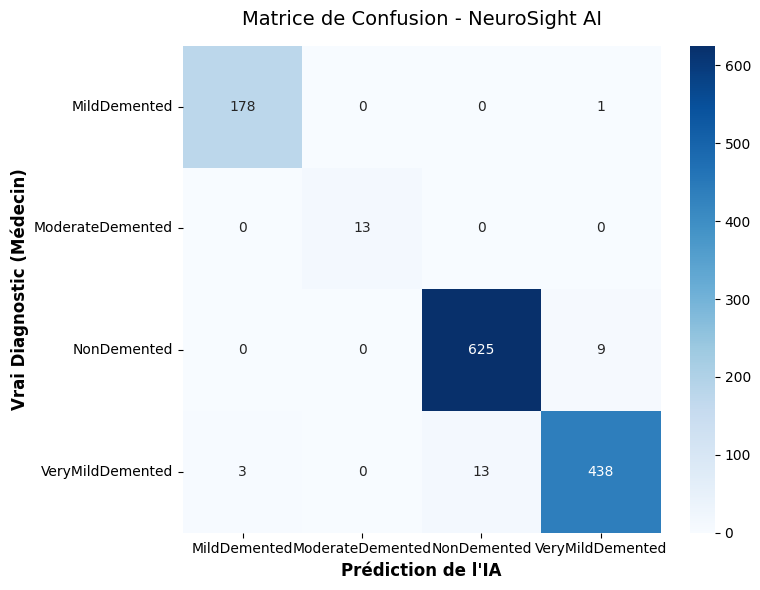


✅ LIVRABLE FINAL DISPONIBLE : 'best_model.pth'


In [15]:
# ==========================================
# CELLULE 3 : L'USINE À INTELLIGENCE (TRAINING & GRID SEARCH)
# ==========================================

# Lancement de la Pipeline Complète
# Rappel : train_loader, test_loader et classes ont été définis dans la Cellule 1
if 'train_loader' in locals() and 'test_loader' in locals():
    print("\n🧠 Démarrage du Workflow MLOps (GridSearch + Training + Evaluation)...")
    
    # Cette ligne fait TOUT : Cherche les paramètres -> Entraîne -> Affiche les graphiques
    best_model, training_history = run_full_training(train_loader, test_loader, classes)
    
else:
    print("❌ Erreur : Les DataLoaders ne sont pas chargés. Exécutez d'abord la Cellule 1.")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


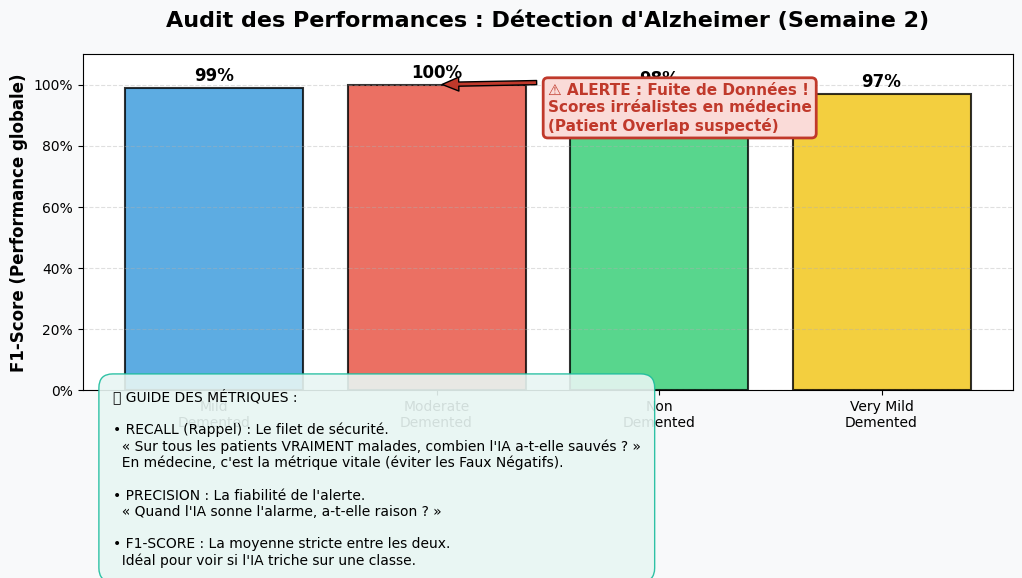

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Les résultats de ton modèle (F1-Scores)
classes = ['Mild\nDemented', 'Moderate\nDemented', 'Non\nDemented', 'Very Mild\nDemented']
f1_scores = [0.99, 1.00, 0.98, 0.97]

# Création d'une figure au design professionnel (style "Rapport Médical")
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#ffffff')

# Barres de scores avec un dégradé de couleurs
bars = ax.bar(classes, f1_scores, color=['#3498db', '#e74c3c', '#2ecc71', '#f1c40f'], 
              edgecolor='black', linewidth=1.5, alpha=0.8)

# Ajout des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval*100:.0f}%", 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- L'EXPLICATION VISUELLE (LES FLÈCHES) ---

# 1. La flèche d'alerte rouge sur le score de 100%
ax.annotate('⚠️ ALERTE : Fuite de Données !\nScores irréalistes en médecine\n(Patient Overlap suspecté)', 
            xy=(1, 1.0), xycoords='data',
            xytext=(1.5, 0.85), textcoords='data',
            arrowprops=dict(facecolor='#c0392b', shrink=0.05, width=3, headwidth=10),
            fontsize=11, fontweight='bold', color='#c0392b',
            bbox=dict(boxstyle="round,pad=0.3", fc="#fadbd8", ec="#c0392b", lw=2))

# 2. Panneau d'explication des Métriques pour Leila
texte_metriques = (
    "🧠 GUIDE DES MÉTRIQUES :\n\n"
    "• RECALL (Rappel) : Le filet de sécurité.\n"
    "  « Sur tous les patients VRAIMENT malades, combien l'IA a-t-elle sauvés ? »\n"
    "  En médecine, c'est la métrique vitale (éviter les Faux Négatifs).\n\n"
    "• PRECISION : La fiabilité de l'alerte.\n"
    "  « Quand l'IA sonne l'alarme, a-t-elle raison ? »\n\n"
    "• F1-SCORE : La moyenne stricte entre les deux.\n"
    "  Idéal pour voir si l'IA triche sur une classe."
)

# Placement du panneau d'explication
fig.text(0.15, 0.15, texte_metriques, fontsize=10, 
         bbox=dict(facecolor='#e8f6f3', edgecolor='#1abc9c', boxstyle='round,pad=1', alpha=0.9))

# Finitions du graphique
ax.set_ylim(0, 1.1)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax.set_ylabel("F1-Score (Performance globale)", fontsize=12, fontweight='bold')
ax.set_title("Audit des Performances : Détection d'Alzheimer (Semaine 2)", fontsize=16, fontweight='heavy', pad=20)

plt.subplots_adjust(bottom=0.4) # Fait de la place pour le texte
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()